/tmp/ipykernel_5558/3814343817.py:73: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 80 negative Z values that have been clipped to zero
  rgb = lab2rgb(LAB)


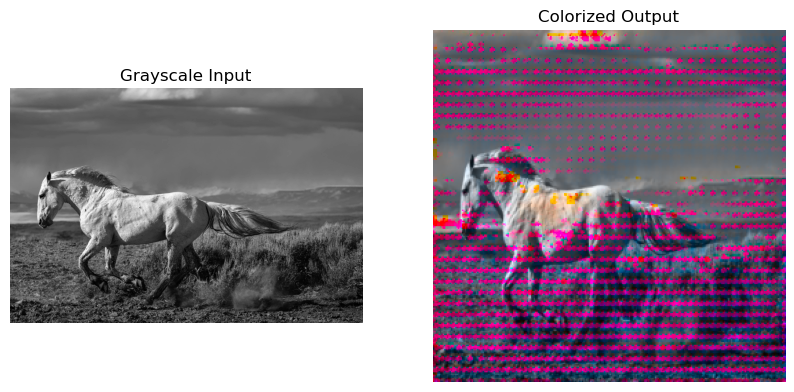

In [1]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Generator (same as training)
# ------------------------------
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 2, 4, 2, 1), nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# ------------------------------
# COLORIZATION FUNCTION
# ------------------------------
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from skimage.color import lab2rgb

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
model = Generator()
checkpoint_path = "/home/mmanani/ImageColourizationDataSet/checkpoints/gan_checkpoint.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"]["G"])
model.to(device)
model.eval()

to_tensor = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

def colorize(img_path):
    img_gray = Image.open(img_path).convert("L")
    L = to_tensor(img_gray).unsqueeze(0).to(device)   # (1,1,256,256)

    with torch.no_grad():
        AB = model(L).cpu()[0]                        # (2,256,256)

    # Denormalize L and AB
    L = L.cpu()[0][0].numpy() * 50 + 50               # L in range [0..100]
    AB = AB.numpy() * 128                             # AB in range [-128..127]

    # Combine to LAB
    LAB = np.zeros((256,256,3))
    LAB[:,:,0] = L
    LAB[:,:,1:] = AB.transpose(1,2,0)

    # LAB → RGB
    rgb = lab2rgb(LAB)

    # Plot both
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title("Grayscale Input")
    plt.imshow(img_gray, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Colorized Output")
    plt.imshow(rgb)
    plt.axis("off")

    plt.show()


#colorize("/home/mmanani/mtechpracticals/semester-4/6.jpg")
colorize('/home/mmanani/ImageColourizationDataSet/Wild-Horse-Wyoming-3284-Edit-Edit-BW.jpg')


In [2]:
import torch

checkpoint_path = "/home/mmanani/ImageColourizationDataSet/checkpoints/gan_checkpoint.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

print("\n✅ Checkpoint Keys:", checkpoint.keys())
print("\n✅ Model State Dict Keys:", checkpoint["model_state_dict"].keys())



✅ Checkpoint Keys: dict_keys(['epoch', 'batch', 'model_state_dict', 'optimizer_state_dict', 'loss'])

✅ Model State Dict Keys: dict_keys(['G', 'D'])


Model loaded!
Generator output stats (before clamp): -0.01254286989569664 1.0 0.12306949496269226


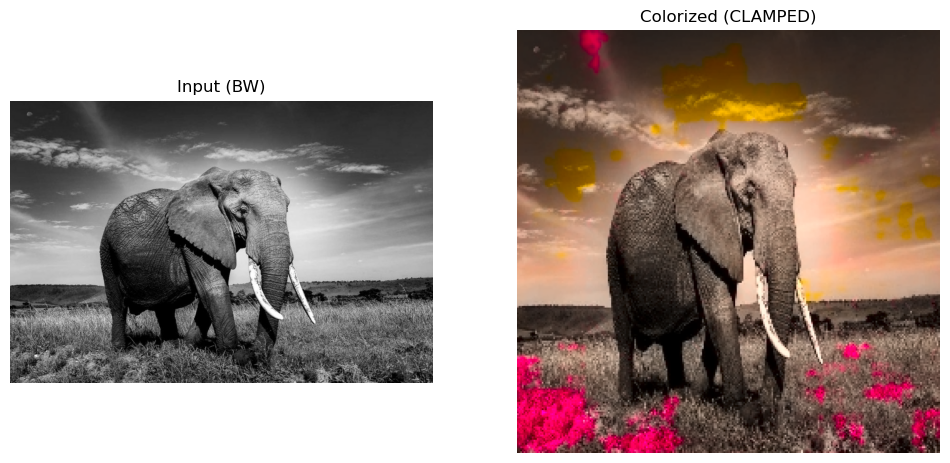

SAVED: clamped_horse.jpg


In [28]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import lab2rgb

# -----------------------------
# 1. LOAD MODEL
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = "/home/mmanani/ImageColourizationDataSet/checkpoints/gan_checkpoint.pth"

class Generator(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, 64, 4, 2, 1), torch.nn.ReLU(),
            torch.nn.Conv2d(64, 128, 4, 2, 1), torch.nn.BatchNorm2d(128), torch.nn.ReLU(),
            torch.nn.Conv2d(128, 256, 4, 2, 1), torch.nn.BatchNorm2d(256), torch.nn.ReLU()
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(256, 128, 4, 2, 1), torch.nn.BatchNorm2d(128), torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(128, 64, 4, 2, 1), torch.nn.BatchNorm2d(64), torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(64, 2, 4, 2, 1), torch.nn.Tanh()
        )
    def forward(self, x): 
        return self.decoder(self.encoder(x))

G = Generator().to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
G.load_state_dict(checkpoint['model_state_dict']['G'])
G.eval()
print("Model loaded!")

# -----------------------------
# 2. COLORIZE WITH CLAMP
# -----------------------------
# Section 6: Inference and Visualization (Optional)
def colorize_image(image_path, G, device='cuda'):
    """
    Colorizes a grayscale image using trained Generator (G).
    Uses STANDARD LAB scaling: L/100, ab/128 → [0,1] & [-1,1]
    """
    G.eval()
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load {image_path}")

    # ✅ fix scaling consistency
    l_resized = cv2.resize(img, (256, 256)) / 255.0# changed from /255.0 to /100.0

    l_tensor = torch.from_numpy(l_resized).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        ab_pred = G(l_tensor)

    # Diagnostic check before clamping
    print("Generator output stats (before clamp):", 
          ab_pred.min().item(), ab_pred.max().item(), ab_pred.mean().item())  # ✅ diagnostic print

    ab_pred = torch.clamp(ab_pred, -1, 1)
    ab_pred = ab_pred.squeeze(0).cpu().numpy() * 128  # ✅ denormalize ab to [-128, 128]
    ab_pred = ab_pred.transpose((1, 2, 0))

    # ✅ add Gaussian smoothing for smoother chroma
    ab_pred = cv2.GaussianBlur(ab_pred, (5, 5), 0)

    L_rescaled = l_resized * 100.0                    # ✅ denormalize L to [0, 100]

    lab_out = np.zeros((256, 256, 3), dtype=np.float32)
    lab_out[:, :, 0] = L_rescaled
    lab_out[:, :, 1:] = ab_pred

    rgb_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)
    rgb_out = np.clip(rgb_out, 0, 1)  # normalize final output

    return (rgb_out * 255).astype(np.uint8)

# 3. RUN
# -----------------------------
sample_path = '/home/mmanani/ImageColourizationDataSet/63775aec-17ca-4b4b-a147-fc0d3d426f91.jpg'
colorized = colorize_image(sample_path,G)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Input (BW)")
plt.imshow(cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Colorized (CLAMPED)")
plt.imshow(colorized)
plt.axis('off')
plt.show()

cv2.imwrite("clamped_horse.jpg", cv2.cvtColor(colorized, cv2.COLOR_RGB2BGR))
print("SAVED: clamped_horse.jpg")